In [1]:
# Feature Selection: per-attack analysis
# Goal: identify which features matter for each attack type,
# remove features that are irrelevant across all attacks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load data
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    data = pd.read_csv('/content/drive/MyDrive/cicids2017_combined.csv')
    print(f"Loaded from Drive: {data.shape}")
except:
    from google.colab import files
    uploaded = files.upload()
    data = pd.read_csv('cicids2017_combined.csv')
    print(f"Loaded from upload: {data.shape}")

data.columns = data.columns.str.strip()
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)
print(f"After cleaning: {data.shape}")

Mounted at /content/drive
Loaded from Drive: (2830743, 79)
After cleaning: (2827876, 79)


In [3]:
# Attack type distribution
print("Attack distribution:")
print(data['Label'].value_counts())
print(f"\nTotal attack types: {data['Label'].nunique() - 1}")  # minus BENIGN

Attack distribution:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Total attack types: 14


In [5]:
# Remove low variance features

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if 'Label' in feature_cols:
  feature_cols.remove('Label')

variances = data[feature_cols].var()
low_var = variances[variances < 0.01].index.tolist()

print(f"Total features : {len(feature_cols)}\n")
print(f"Low variance features to remove ({len(low_var)}):")
for f in low_var:
  print(f"   {f}: var={variances[f]:.6f}, unique={data[f].nunique()}")

Total features : 78

Low variance features to remove (12):
   Bwd PSH Flags: var=0.000000, unique=1
   Fwd URG Flags: var=0.000111, unique=2
   Bwd URG Flags: var=0.000000, unique=1
   RST Flag Count: var=0.000243, unique=2
   CWE Flag Count: var=0.000111, unique=2
   ECE Flag Count: var=0.000244, unique=2
   Fwd Avg Bytes/Bulk: var=0.000000, unique=1
   Fwd Avg Packets/Bulk: var=0.000000, unique=1
   Fwd Avg Bulk Rate: var=0.000000, unique=1
   Bwd Avg Bytes/Bulk: var=0.000000, unique=1
   Bwd Avg Packets/Bulk: var=0.000000, unique=1
   Bwd Avg Bulk Rate: var=0.000000, unique=1


In [6]:
# Remove identifier features (not behavioral)
identifier_features = ['Destination Port']
feature_cols = [f for f in feature_cols if f not in identifier_features]
print(f"Removed identifier features: {identifier_features}")

Removed identifier features: ['Destination Port']


In [7]:
# Remove highly correlated features (duplicated features)

remaining = [f for f in feature_cols if f not in low_var]
corr = data[remaining].corr().abs()

to_drop = set()
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i,j] > 0.99:
            to_drop.add(corr.columns[j])

print(f"Highly correlated features to remove ({len(to_drop)}):")
for f in sorted(to_drop):
    print(f"  {f}")

remaining_after_corr = [f for f in remaining if f not in to_drop]
print(f"\nFeatures remaining: {len(remaining_after_corr)}")

Highly correlated features to remove (15):
  Average Packet Size
  Avg Bwd Segment Size
  Avg Fwd Segment Size
  Fwd Header Length.1
  Fwd IAT Max
  Fwd IAT Total
  Idle Max
  Idle Min
  SYN Flag Count
  Subflow Bwd Bytes
  Subflow Bwd Packets
  Subflow Fwd Bytes
  Subflow Fwd Packets
  Total Backward Packets
  Total Length of Bwd Packets

Features remaining: 50


In [8]:
# Per-attack feature importance using Random Forest
# For each attack type, train RF (attack vs benign) and rank features

data['is_attack'] = (data['Label'] != 'BENIGN').astype(int)
attack_types = [l for l in data['Label'].unique() if l != 'BENIGN']

importance_dict = {}

for attack in attack_types:
    # Binary: this attack vs benign
    subset = data[(data['Label'] == attack) | (data['Label'] == 'BENIGN')]
    X_sub = subset[remaining_after_corr]
    y_sub = (subset['Label'] == attack).astype(int)

    # Quick RF (small sample for speed)
    sample_size = min(50000, len(subset))
    sample_idx = np.random.choice(len(subset), sample_size, replace=False)
    X_sample = X_sub.iloc[sample_idx]
    y_sample = y_sub.iloc[sample_idx]

    rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_sample, y_sample)

    importance_dict[attack] = pd.Series(rf.feature_importances_, index=remaining_after_corr)
    top5 = importance_dict[attack].nlargest(5)
    print(f"\n{attack} — top 5 features:")
    for feat, imp in top5.items():
        print(f"  {feat}: {imp:.4f}")

print("\nDone — all attack types analyzed.")


DDoS — top 5 features:
  Bwd Packet Length Std: 0.1446
  Packet Length Variance: 0.0984
  Bwd Packet Length Mean: 0.0821
  Bwd Packet Length Max: 0.0755
  Packet Length Std: 0.0682

PortScan — top 5 features:
  PSH Flag Count: 0.0881
  Total Length of Fwd Packets: 0.0754
  Packet Length Variance: 0.0690
  Flow Bytes/s: 0.0575
  Packet Length Mean: 0.0574

Bot — top 5 features:
  Init_Win_bytes_forward: 0.0792
  Flow Duration: 0.0566
  Bwd IAT Min: 0.0515
  Bwd Packets/s: 0.0510
  Fwd IAT Std: 0.0493

Infiltration — top 5 features:
  Bwd IAT Max: 0.1016
  act_data_pkt_fwd: 0.0994
  Active Mean: 0.0934
  Flow Bytes/s: 0.0933
  Bwd IAT Mean: 0.0688

Web Attack � Brute Force — top 5 features:
  Fwd IAT Min: 0.2392
  Flow IAT Min: 0.1389
  Init_Win_bytes_backward: 0.0584
  Bwd Packets/s: 0.0390
  Flow IAT Max: 0.0377

Web Attack � XSS — top 5 features:
  Fwd IAT Min: 0.3304
  Flow IAT Min: 0.0993
  Flow Packets/s: 0.0560
  Fwd IAT Mean: 0.0463
  Fwd IAT Std: 0.0459

Web Attack � Sql Inject

In [9]:
# Aggregate importance across all attacks
# Keep features that are important for at least one attack type

importance_df = pd.DataFrame(importance_dict)
importance_df['max_importance'] = importance_df.max(axis=1)
importance_df['mean_importance'] = importance_df.mean(axis=1)

# Features with max importance > 0.02 across any attack
selected_features = importance_df[importance_df['max_importance'] > 0.02].index.tolist()

print(f"Selected features: {len(selected_features)} / {len(remaining_after_corr)}")
print(f"\nSelected:")
for f in selected_features:
    print(f"  {f}: max={importance_df.loc[f,'max_importance']:.4f}, mean={importance_df.loc[f,'mean_importance']:.4f}")

dropped = [f for f in remaining_after_corr if f not in selected_features]
print(f"\nDropped ({len(dropped)}):")
for f in dropped:
    print(f"  {f}: max={importance_df.loc[f,'max_importance']:.4f}")

Selected features: 47 / 50

Selected:
  Flow Duration: max=0.0566, mean=0.0225
  Total Fwd Packets: max=0.0420, mean=0.0142
  Total Length of Fwd Packets: max=0.0754, mean=0.0295
  Fwd Packet Length Max: max=0.0624, mean=0.0259
  Fwd Packet Length Min: max=0.0264, mean=0.0071
  Fwd Packet Length Mean: max=0.0738, mean=0.0239
  Fwd Packet Length Std: max=0.0848, mean=0.0199
  Bwd Packet Length Max: max=0.0838, mean=0.0356
  Bwd Packet Length Min: max=0.0431, mean=0.0071
  Bwd Packet Length Mean: max=0.0821, mean=0.0336
  Bwd Packet Length Std: max=0.2268, mean=0.0569
  Flow Bytes/s: max=0.0933, mean=0.0242
  Flow Packets/s: max=0.0560, mean=0.0242
  Flow IAT Mean: max=0.0429, mean=0.0180
  Flow IAT Std: max=0.0308, mean=0.0161
  Flow IAT Max: max=0.0672, mean=0.0277
  Flow IAT Min: max=0.1389, mean=0.0363
  Fwd IAT Mean: max=0.0463, mean=0.0201
  Fwd IAT Std: max=0.0493, mean=0.0190
  Fwd IAT Min: max=0.3304, mean=0.0706
  Bwd IAT Total: max=0.0322, mean=0.0083
  Bwd IAT Mean: max=0.068

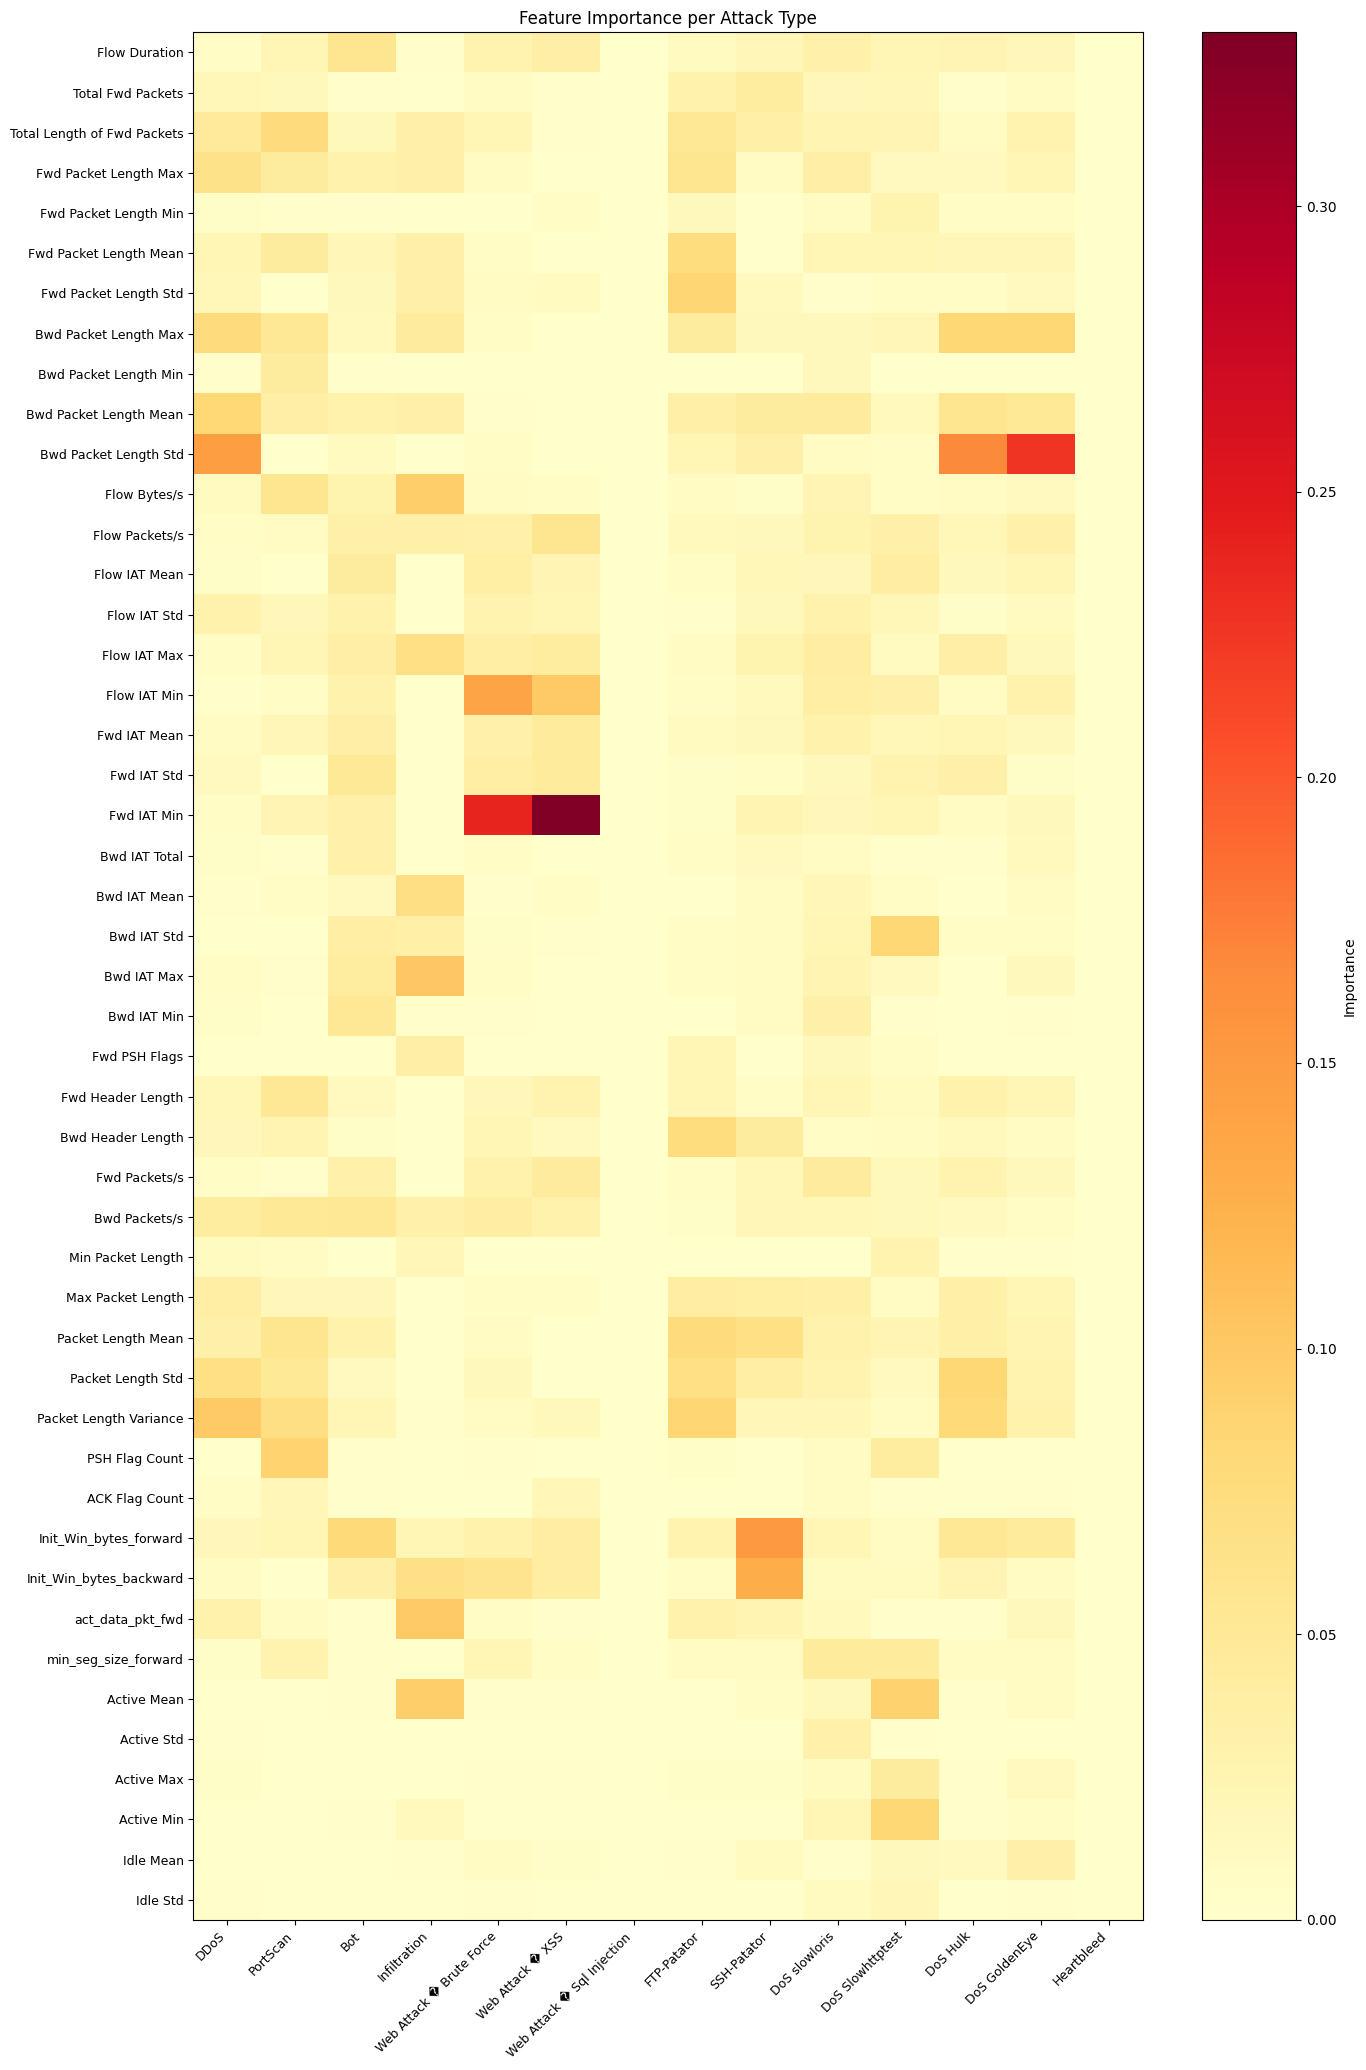

In [10]:
# Visualize per-attack feature importance heatmap
fig, ax = plt.subplots(figsize=(14, len(selected_features) * 0.4 + 2))

heatmap_data = importance_df.loc[selected_features, attack_types]
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(attack_types)))
ax.set_xticklabels(attack_types, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(selected_features)))
ax.set_yticklabels(selected_features, fontsize=9)
ax.set_title('Feature Importance per Attack Type')
plt.colorbar(im, label='Importance')
plt.tight_layout()
plt.show()

In [11]:
# Save cleaned dataset with selected features only
final_cols = identifier_features + selected_features + ['Label']
data_selected = data[final_cols]

print(f"Original: {data.shape[1]} columns")
print(f"Selected: {data_selected.shape[1]} columns")
print(f"Rows: {data_selected.shape[0]}")

# Save to Drive if mounted, otherwise download
try:
    save_path = '/content/drive/MyDrive/cicids2017_selected.csv'
    data_selected.to_csv(save_path, index=False)
    print(f"\nSaved to: {save_path}")
except:
    data_selected.to_csv('cicids2017_selected.csv', index=False)
    from google.colab import files
    files.download('cicids2017_selected.csv')
    print("\nDownloaded as cicids2017_selected.csv")

Original: 80 columns
Selected: 49 columns
Rows: 2827876

Saved to: /content/drive/MyDrive/cicids2017_selected.csv
